In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv(r'C:\Users\Admin\Documents\Machine Learning\student1.csv')
df.head(3)

,name,gmat,gpa,exp,admitted,country
0,samir,780,4.0,3,1,Ind
1,kaushal,750,3.9,4,1,Ind
2,nandan,690,3.3,3,0,Ind


In [3]:
df.drop(columns=['name', 'country'], inplace=True)


In [4]:
df.isnull().sum()

gmat        0
gpa         0
exp         0
admitted    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(4)

In [6]:
df.drop_duplicates(inplace=True)

<Axes: ylabel='gmat'>

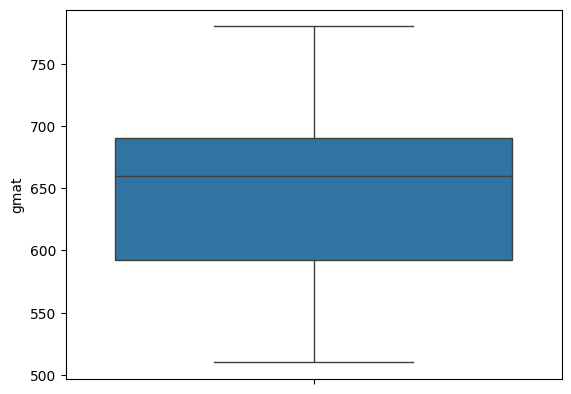

In [7]:
import seaborn as sns 
sns.boxplot(data=df, y="gmat")

In [8]:
df["exp"].describe()

count    38.000000
mean      3.894737
std       3.754561
min       1.000000
25%       2.000000
50%       4.000000
75%       5.000000
max      24.000000
Name: exp, dtype: float64

In [9]:
q1 = 2.0
q3 = 5.0
IQR = q3 - q1 

In [10]:
ub = q3 + 1.5*IQR 
lb = q1 - 1.5*IQR

In [11]:
df = df[(df["exp"]>lb)&(df["exp"]<ub)]

<Axes: xlabel='gmat', ylabel='exp'>

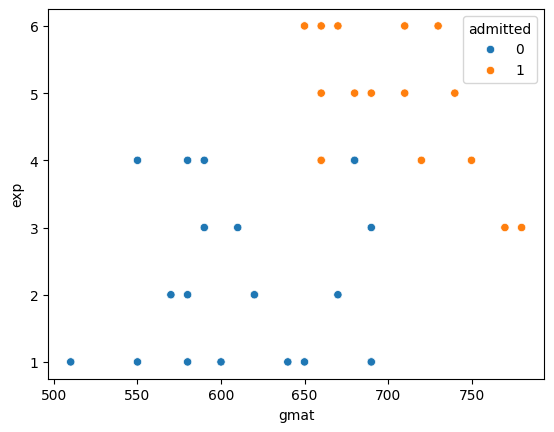

In [12]:
sns.scatterplot(data=df, x="gmat", y="exp", hue="admitted")

In [13]:
x = df.drop("admitted", axis=1)
y = df["admitted"]

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.svm import SVC 


In [16]:
parameters = {
    "C": [0.3, 0.5], 
    "kernel": ["linear", "rbf", "poly"]
}

In [17]:
#model = SVC(C = 1.0, kernel='rbf', degree=3, gamma='scale')
model = SVC()
#model = SVC(C = 1.0, kernel='poly', degree=3, gamma='scale')
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [18]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(SVC(), parameters)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'C': 0.3, 'kernel': 'linear'}


In [19]:
y_predict = model.predict(X_test)

In [20]:
model.score(X_test, y_test)

0.625

In [21]:
model.score(X_train, y_train)

0.8275862068965517